<a href="https://colab.research.google.com/github/Praveenachitikena/eda_analysis.ipynb/blob/main/web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

products = soup.find_all("div", class_="thumbnail")

titles = []
prices = []
descriptions = []

for product in products:

    title = product.find("a", class_="title").text.strip()
    titles.append(title)

    price = product.find("h4", class_="price").text.strip()
    prices.append(price)

    description = product.find("p", class_="description").text.strip()
    descriptions.append(description)

df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Description": descriptions
})

df.to_csv("laptop_data.csv", index=False)

print(df.head())

               Title    Price  \
0   Asus VivoBook...  $295.99   
1  Prestigio Smar...     $299   
2  Prestigio Smar...     $299   
3      Aspire E1-510  $306.99   
4  Lenovo V110-15...  $321.94   

                                         Description  
0  Asus VivoBook X441NA-GA190 Chocolate Black, 14...  
1  Prestigio SmartBook 133S Dark Grey, 13.3" FHD ...  
2  Prestigio SmartBook 133S Gold, 13.3" FHD IPS, ...  
3    15.6", Pentium N3520 2.16GHz, 4GB, 500GB, Linux  
4  Lenovo V110-15IAP, 15.6" HD, Celeron N3350 1.1...  


               Title    Price  \
0   Asus VivoBook...  $295.99   
1  Prestigio Smar...     $299   
2  Prestigio Smar...     $299   
3      Aspire E1-510  $306.99   
4  Lenovo V110-15...  $321.94   

                                         Description  
0  Asus VivoBook X441NA-GA190 Chocolate Black, 14...  
1  Prestigio SmartBook 133S Dark Grey, 13.3" FHD ...  
2  Prestigio SmartBook 133S Gold, 13.3" FHD IPS, ...  
3    15.6", Pentium N3520 2.16GHz, 4GB, 500GB, Linux  
4  Lenovo V110-15IAP, 15.6" HD, Celeron N3350 1.1...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        117 non-null    object 
 1   Price        117 non-null    float64
 2   Description  117 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.9+ KB
None
                 Title   Price  \
116  Asus ROG Strix...  1799.0   
114  Asus ROG Strix...  1769.0  

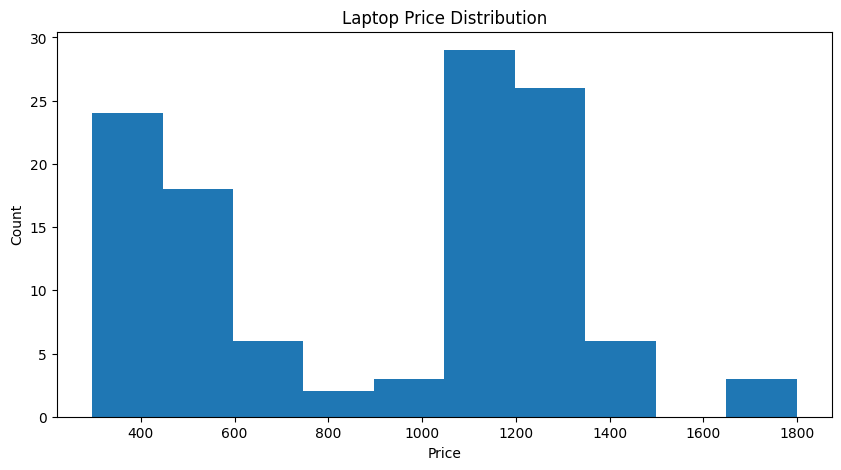

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("laptop_data.csv")


print(df.head())

df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = df["Price"].astype(float)

print(df.info())

top = df.sort_values(by="Price", ascending=False)

print(top.head())

plt.figure(figsize=(10,5))
plt.hist(df["Price"], bins=10)

plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Laptop Price Distribution")

plt.show()